# Pancreatic endocrinogenesis trajectory

**Dataset**: `omicverse.datasets.pancreatic_endocrinogenesis()`
(3 696 cells × 27 998 genes)

**Reference**: Bastidas-Ponce et al. 2019, *Development* 146:dev173849.

Analyse pancreatic β-cell differentiation with `ov.single.Monocle` /
`monocle2_py.Monocle`:

```
Ductal → Ngn3 low EP → Ngn3 high EP → Pre-endocrine → {Alpha, Beta, Delta, Epsilon}
```

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '/scratch/users/steorra/analysis/omicverse_dev/omicverse')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

import omicverse as ov
from omicverse.single import Monocle

np.random.seed(42)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print(f'omicverse version: {ov.__version__}')

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


omicverse version: 2.1.2rc1


## 2. Load the pancreas data

In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()
adata.X = adata.layers['spliced'].copy()
print(f'AnnData: {adata.n_obs} cells × {adata.n_vars} genes')
print(f'\nCell types:\n{adata.obs["clusters"].value_counts()}')

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad
✅ Successfully loaded: 3696 cells × 27998 genes
AnnData: 3696 cells × 27998 genes

Cell types:
clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70
Name: count, dtype: int64


✅ Successfully loaded: 3696 cells × 27998 genes
AnnData: 3696 cells × 27998 genes

Cell types:
clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70
Name: count, dtype: int64


## 3. Build the Monocle analyzer

In [3]:
mono = Monocle(adata)
mono.preprocess(verbose=True)
mono

  Dispersion fit coefs: asymptDisp=0.394423, extraPois=0.17109


Monocle(3696 cells × 27998 genes)
  preprocessed: ✓

## 4. Select ordering genes

For large datasets use `max_genes=1000` to cap the selection (genes are
ranked by dispersion ratio).

Ordering genes: 953


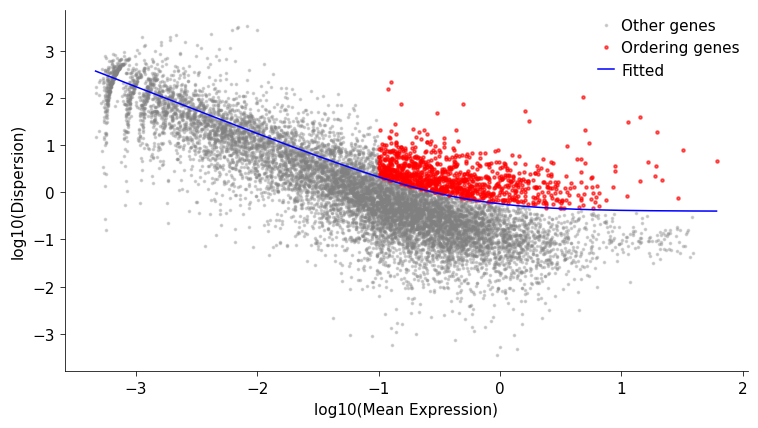

In [4]:
mono.select_ordering_genes(max_genes=1000)
print(f'Ordering genes: {mono.adata.var["use_for_ordering"].sum()}')

mono.plot_ordering_genes(figsize=(7, 4))
plt.show()

## 5. DDRTree reduction + cell ordering

For large datasets `ncenter` is auto-scaled upward so fine branches are
still resolved (otherwise small lineages such as Epsilon would be
missed).

In [10]:
t=mono.reduce_dimension(max_components=2, verbose=True,method='fast')

Learning principal graph with DDRTree
  Auto-scaled ncenter=308 for 3696 cells (R Monocle2 formula would give 128; larger ncenter helps capture fine branches)
Iteration: 0
  Objective: 7051562952.438837
Iteration: 1
  Objective: 10894569436.332813
  delta_obj: 0.54498648
Iteration: 2
  Objective: 7493038715.553721
  delta_obj: 0.31222259
Iteration: 3
  Objective: 7377039304.049389
  delta_obj: 0.01548096
Iteration: 4
  Objective: 7344184520.050474
  delta_obj: 0.00445365
Iteration: 5
  Objective: 7336061116.911506
  delta_obj: 0.00110610
Iteration: 6
  Objective: 7332049129.540840
  delta_obj: 0.00054689
Converged!


In [15]:
%%time
mono.reduce_dimension(max_components=2, verbose=True,method='fast').order_cells()
print('\n' + str(mono))
print(f'Branch points: {mono.branch_points}')

Learning principal graph with DDRTree
  Auto-scaled ncenter=308 for 3696 cells (R Monocle2 formula would give 128; larger ncenter helps capture fine branches)
Iteration: 0
  Objective: 7051563091.948343
Iteration: 1
  Objective: 10894004850.583956
  delta_obj: 0.54490639
Iteration: 2
  Objective: 7492949954.242549
  delta_obj: 0.31219510
Iteration: 3
  Objective: 7377032777.435520
  delta_obj: 0.01547017
Iteration: 4
  Objective: 7344187301.960411
  delta_obj: 0.00445240
Iteration: 5
  Objective: 7336068210.112900
  delta_obj: 0.00110551
Iteration: 6
  Objective: 7332059227.828807
  delta_obj: 0.00054648
Converged!

Monocle(3696 cells × 27998 genes)
  preprocessed: ✓
  ordering genes: 953
  reduced: DDRTree
  ordered: pseudotime [0.00, 37.12], 5 states
Branch points: ['Y_154', 'Y_163']
CPU times: user 3min 30s, sys: 5.4 s, total: 3min 36s
Wall time: 14.3 s


  Objective: 7051563091.560650


Iteration: 1


  Objective: 10893996434.969336
  delta_obj: 0.54490519


Iteration: 2
  Objective: 7492952735.743759
  delta_obj: 0.31219431


Iteration: 3
  Objective: 7377030344.532222
  delta_obj: 0.01547086


Iteration: 4
  Objective: 7344184919.172412
  delta_obj: 0.00445239


Iteration: 5
  Objective: 7336064919.917615
  delta_obj: 0.00110564


Iteration: 6
  Objective: 7331971660.118223
  delta_obj: 0.00055796
Converged!



Monocle(3696 cells × 27998 genes)
  preprocessed: ✓
  ordering genes: 953
  reduced: DDRTree
  ordered: pseudotime [0.00, 37.14], 5 states
Branch points: ['Y_154', 'Y_163']
CPU times: user 51.2 s, sys: 7.24 s, total: 58.4 s
Wall time: 6.47 s


## 6. Trajectory visualization

In [16]:
ov.style()

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0
✅ plot_set complete.



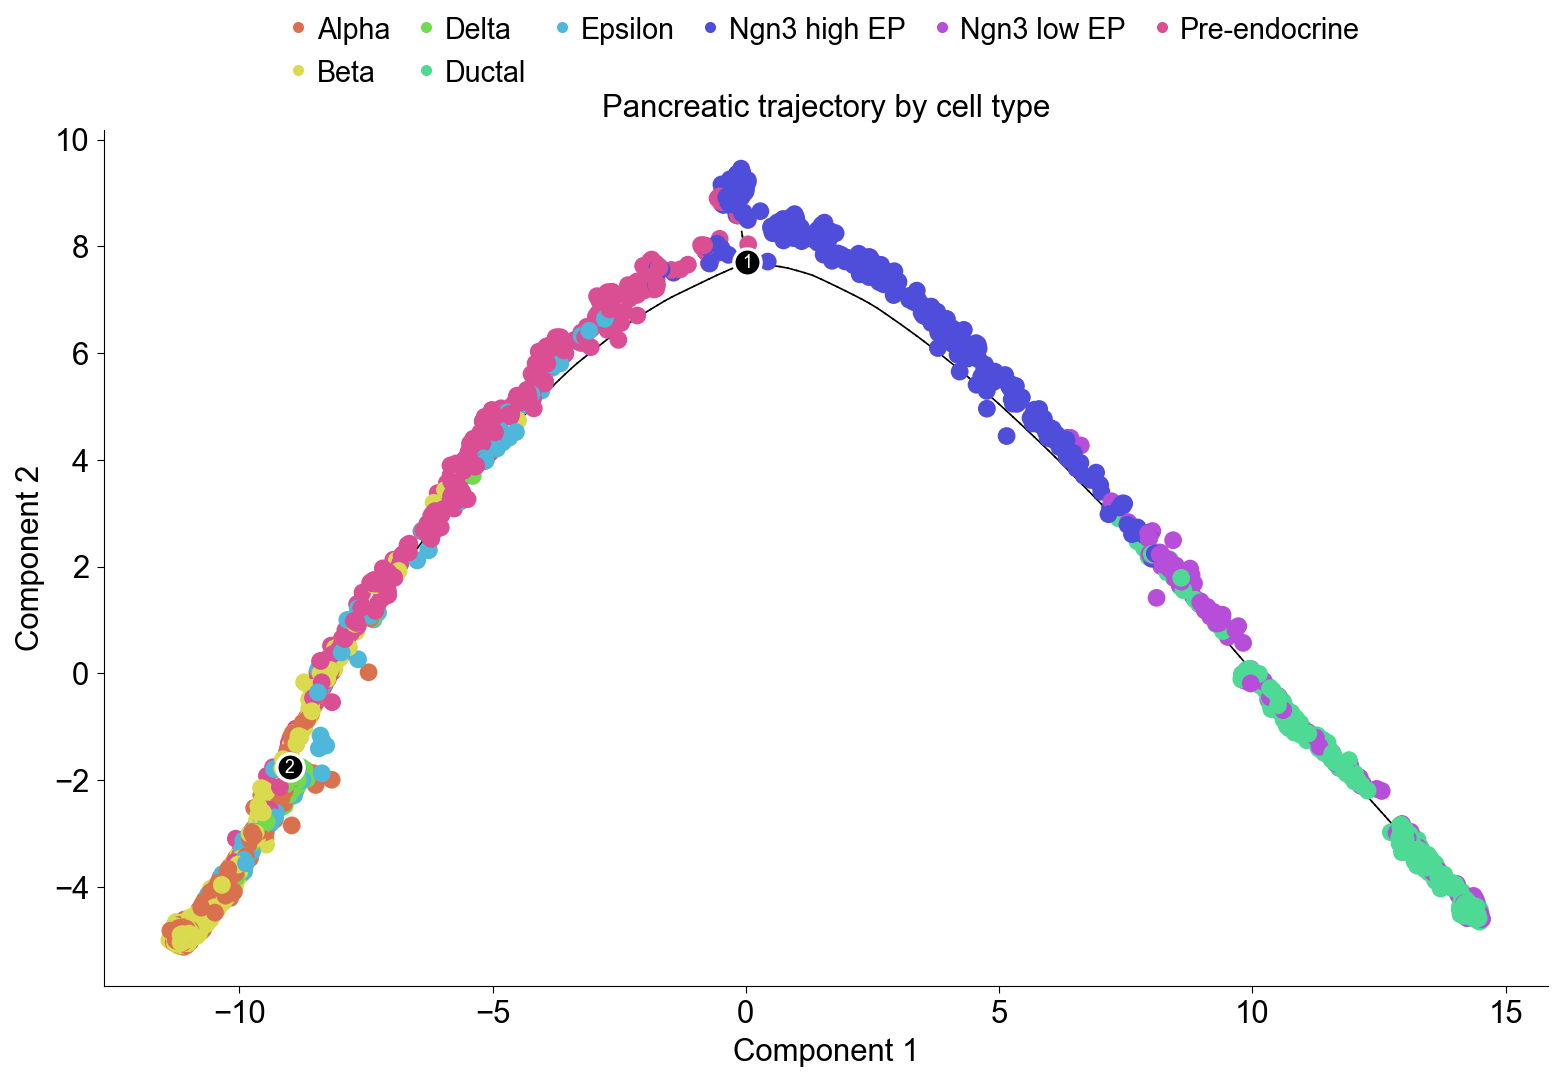

In [20]:
mono.plot_trajectory(color_by='clusters', cell_size=8, figsize=(10, 7))
plt.title('Pancreatic trajectory by cell type')
plt.show()

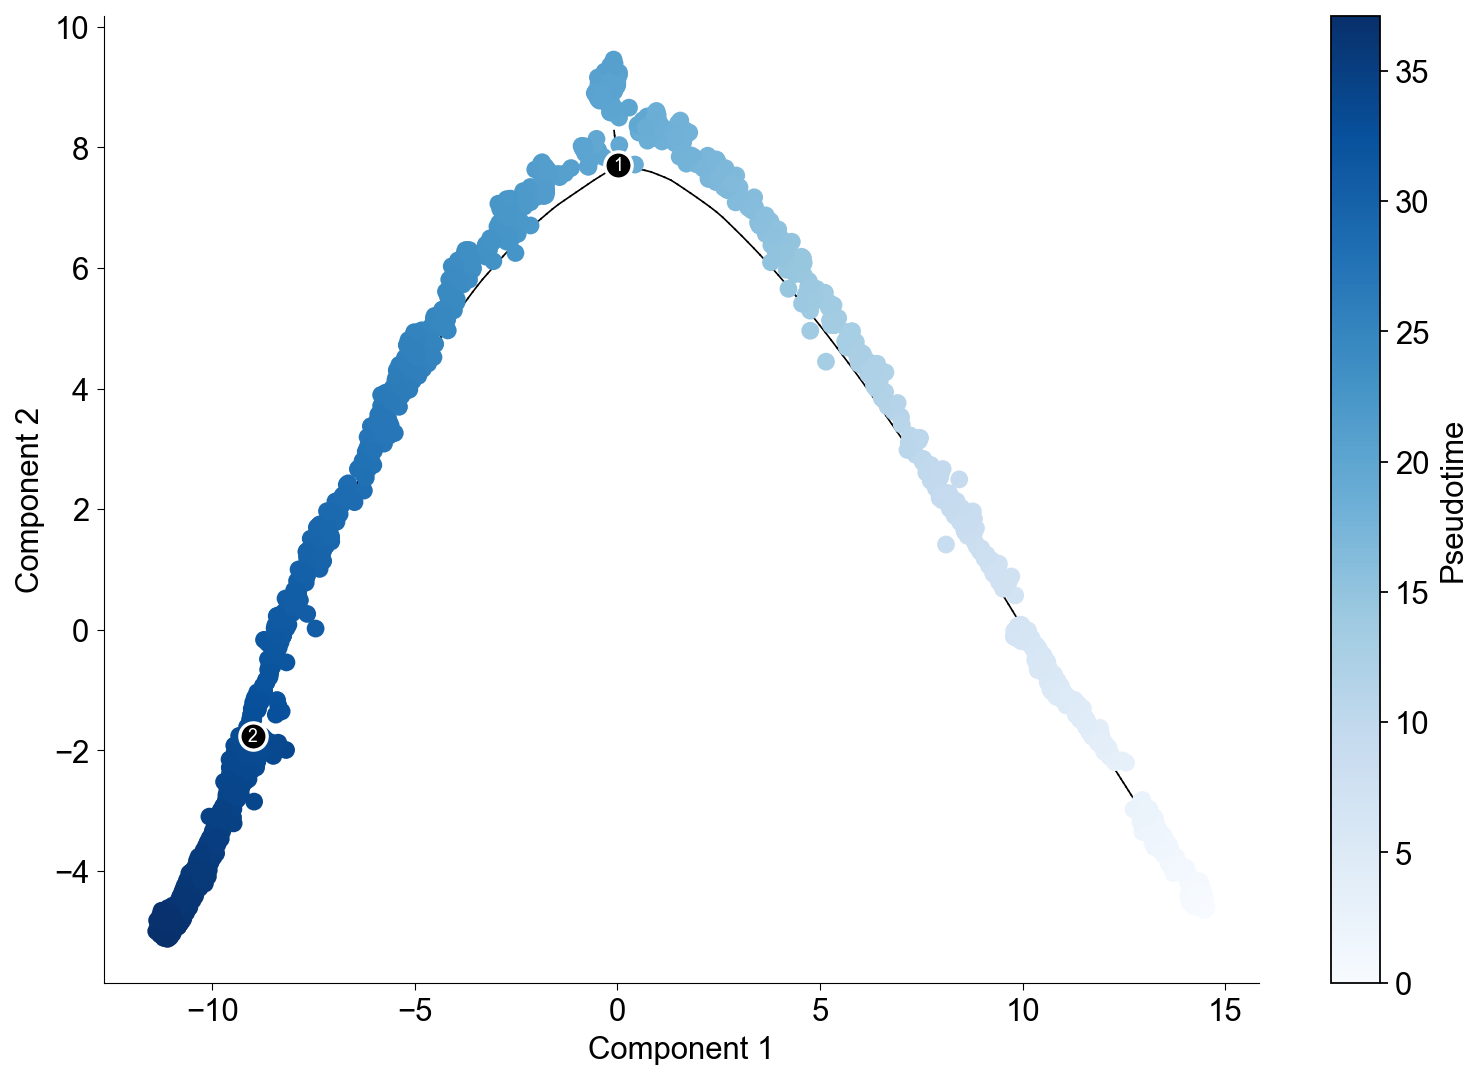

In [18]:
mono.plot_trajectory(color_by='Pseudotime', cell_size=8, figsize=(10, 7))
plt.show()

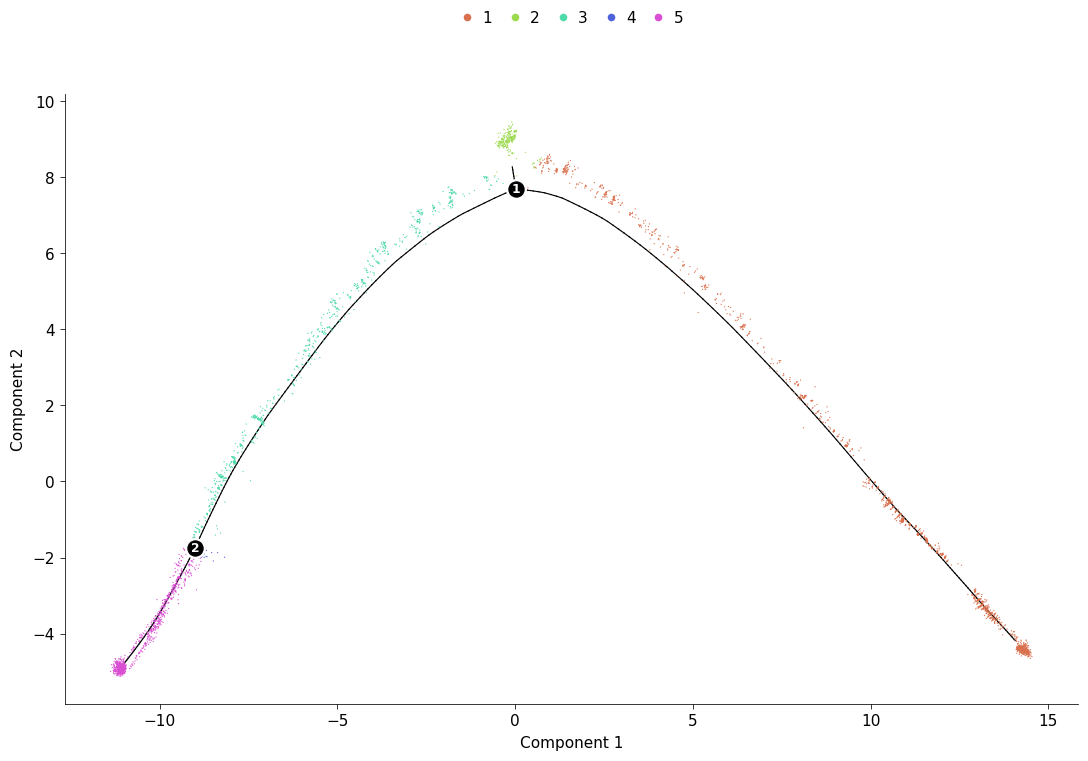

In [8]:
mono.plot_trajectory(color_by='State', cell_size=0.8, figsize=(10, 7))
plt.show()

## 7. State ↔ cell-type correspondence

Sanity-check that the inferred `State` aligns with known cell types.

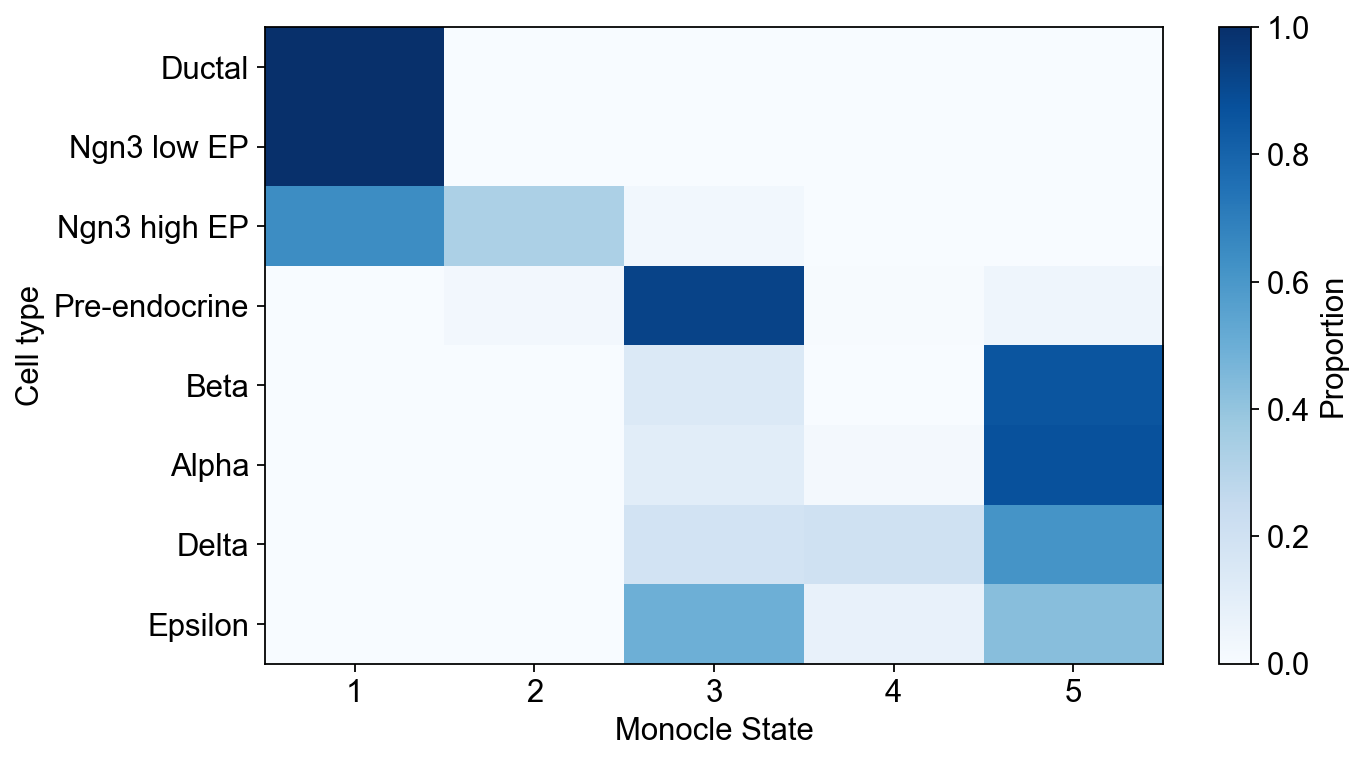

In [9]:
import pandas as pd
state_cluster = pd.crosstab(mono.adata.obs['State'], mono.adata.obs['clusters'])
state_cluster_norm = state_cluster.div(state_cluster.sum(axis=0), axis=1)

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
im = ax.imshow(state_cluster_norm.T, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(state_cluster_norm.index)))
ax.set_xticklabels(state_cluster_norm.index)
ax.set_yticks(range(len(state_cluster_norm.columns)))
ax.set_yticklabels(state_cluster_norm.columns)
ax.set_xlabel('Monocle State')
ax.set_ylabel('Cell type')
plt.colorbar(im, ax=ax, label='Proportion')
plt.tight_layout()
plt.show()

## 8. Complex trajectory (tree layout)

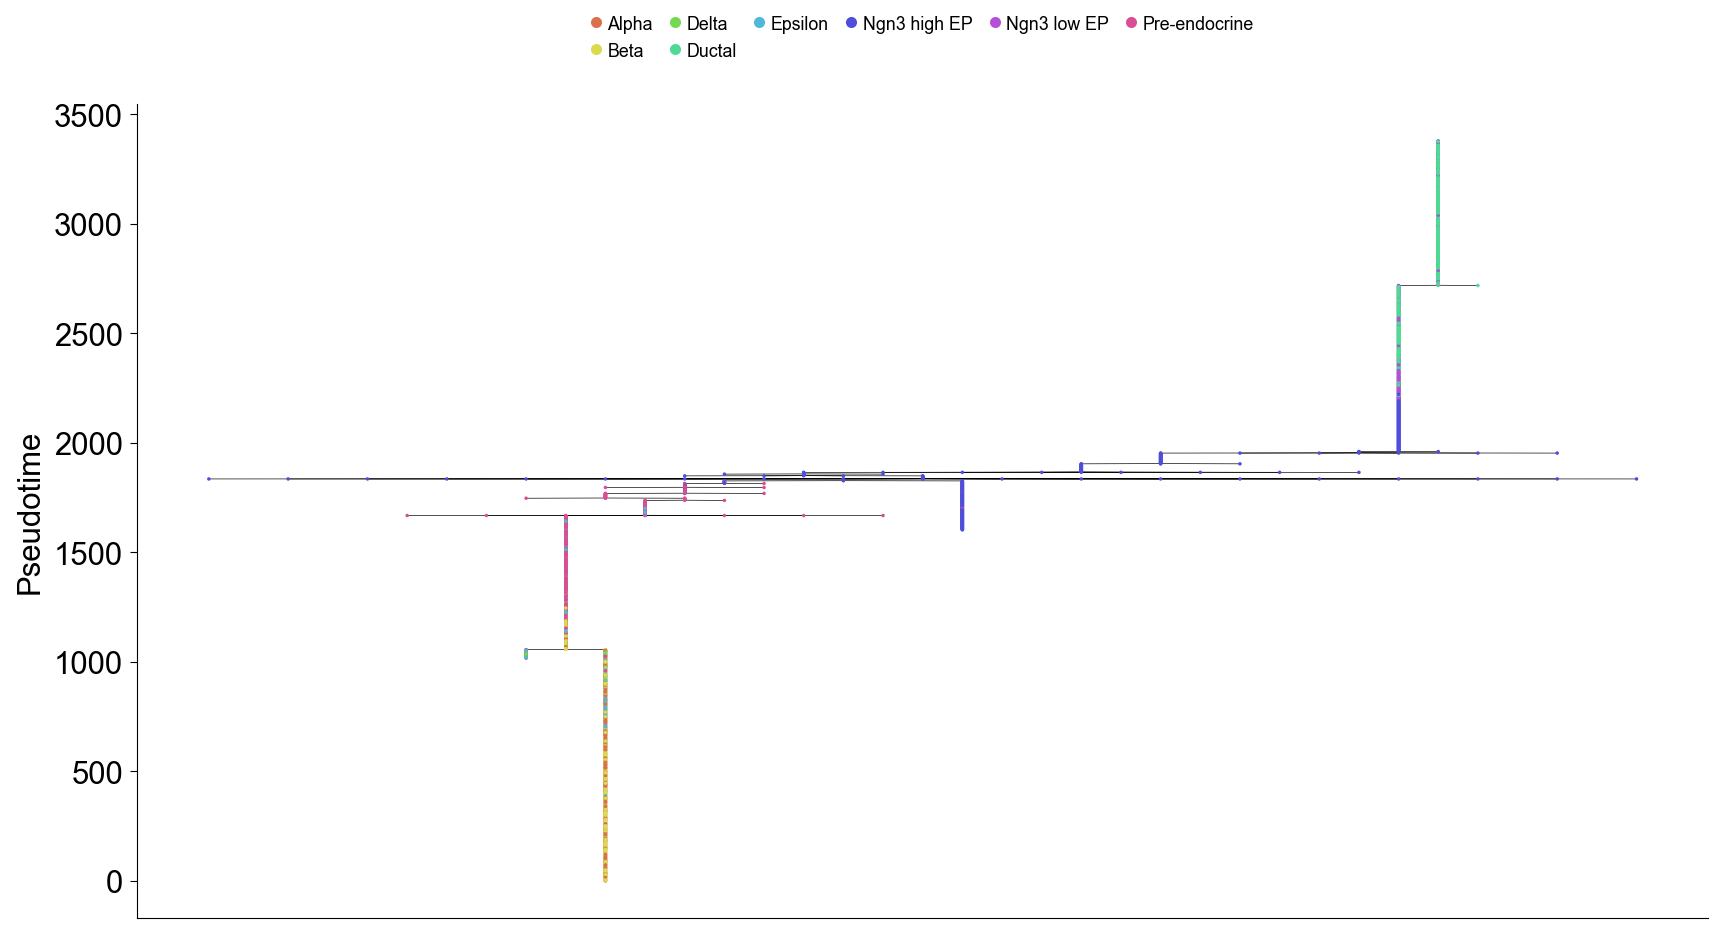

In [10]:
mono.plot_complex_cell_trajectory(color_by='clusters',
                                   cell_size=0.5, cell_link_size=0.3,
                                   figsize=(11, 6))
plt.show()

## 9. Differential expression along pseudotime

In [11]:
%%time
# Only test ordering genes to keep things fast
ordering_genes = mono.adata.var_names[mono.adata.var['use_for_ordering']].tolist()
mono_ord = Monocle(mono.adata[:, ordering_genes].copy())

de = mono_ord.differential_gene_test(cores=-1)
sig = de[de['qval'] < 0.01]
print(f'\nSignificant genes (qval<0.01): {len(sig)}/{len(de)}')
de.sort_values('qval').head(10)[['pval','qval','status']]


Significant genes (qval<0.01): 335/953
CPU times: user 211 ms, sys: 70.9 ms, total: 282 ms
Wall time: 7.12 s


           pval  qval status
index                       
Tmem51      0.0   0.0     OK
Ncs1        0.0   0.0     OK
Gpsm1       0.0   0.0     OK
Npdc1       0.0   0.0     OK
Nrarp       0.0   0.0     OK
Fam107b     0.0   0.0     OK
Nmt2        0.0   0.0     OK
Hspa4l      0.0   0.0     OK
Trp53inp1   0.0   0.0     OK
Fam213b     0.0   0.0     OK

## 10. Pseudotime heatmap

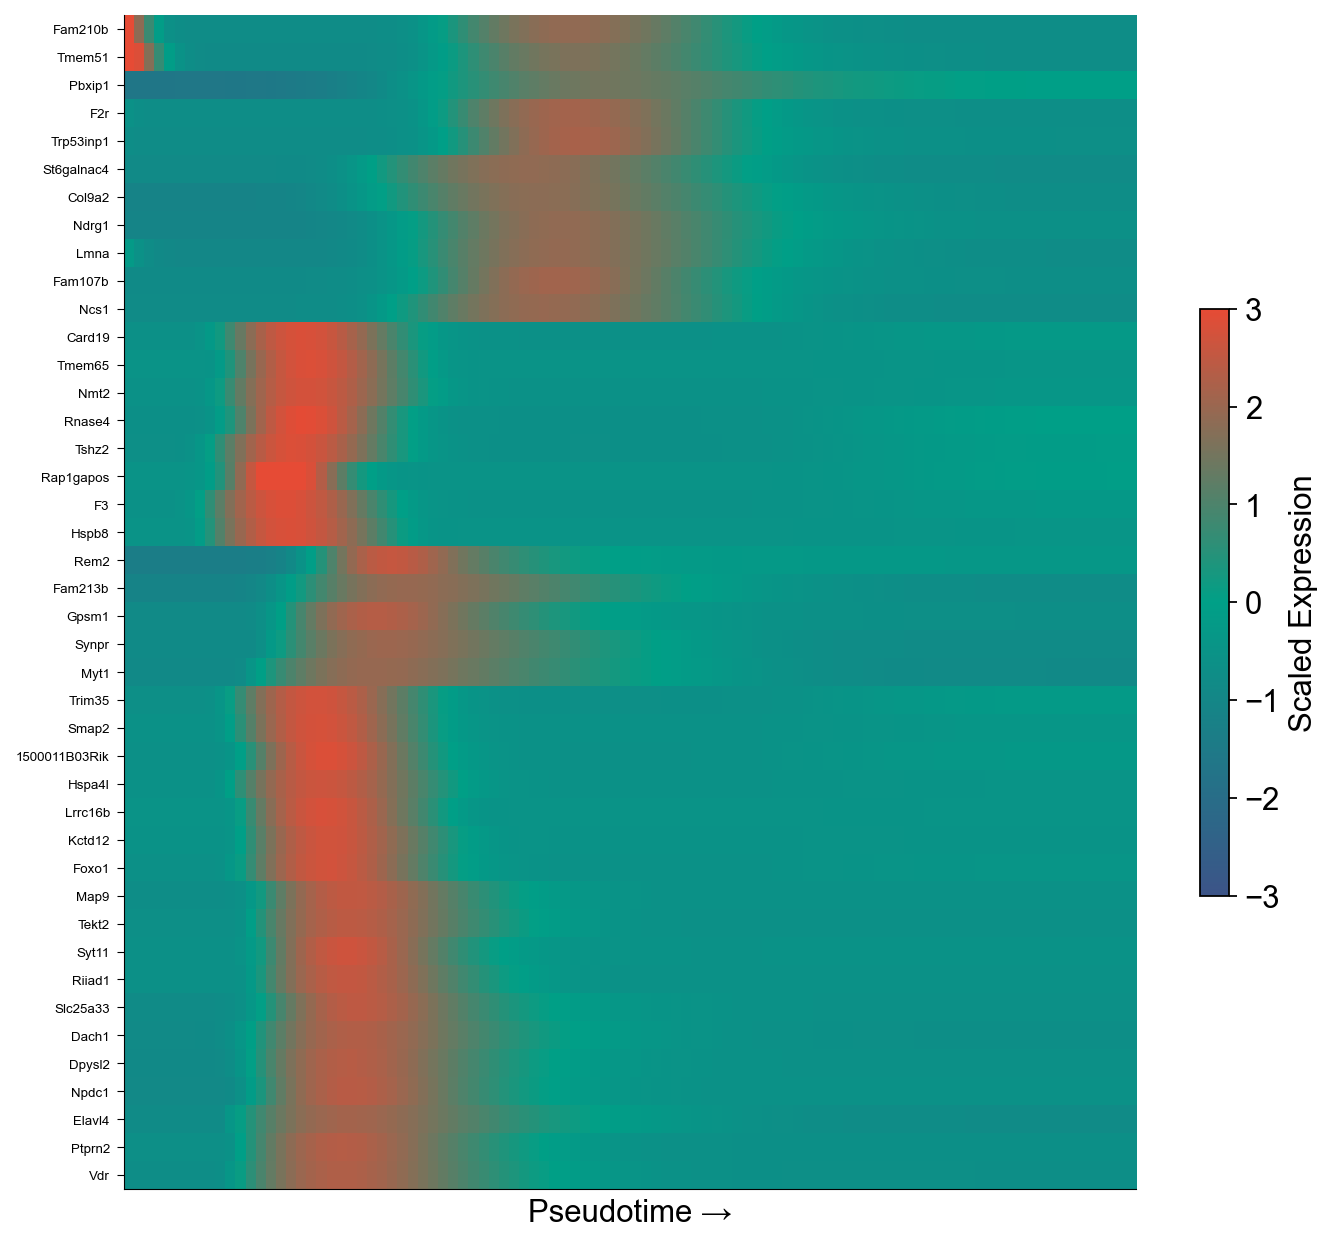

In [12]:
top50 = de.sort_values('pval').head(50).index.tolist()
mono.plot_pseudotime_heatmap(genes=top50, num_clusters=4,
                              show_rownames=True, figsize=(9, 8))
plt.show()

## 11. Classical pancreas markers

Markers: ['Ins1', 'Ins2', 'Gcg', 'Sst', 'Ghrl', 'Neurog3']


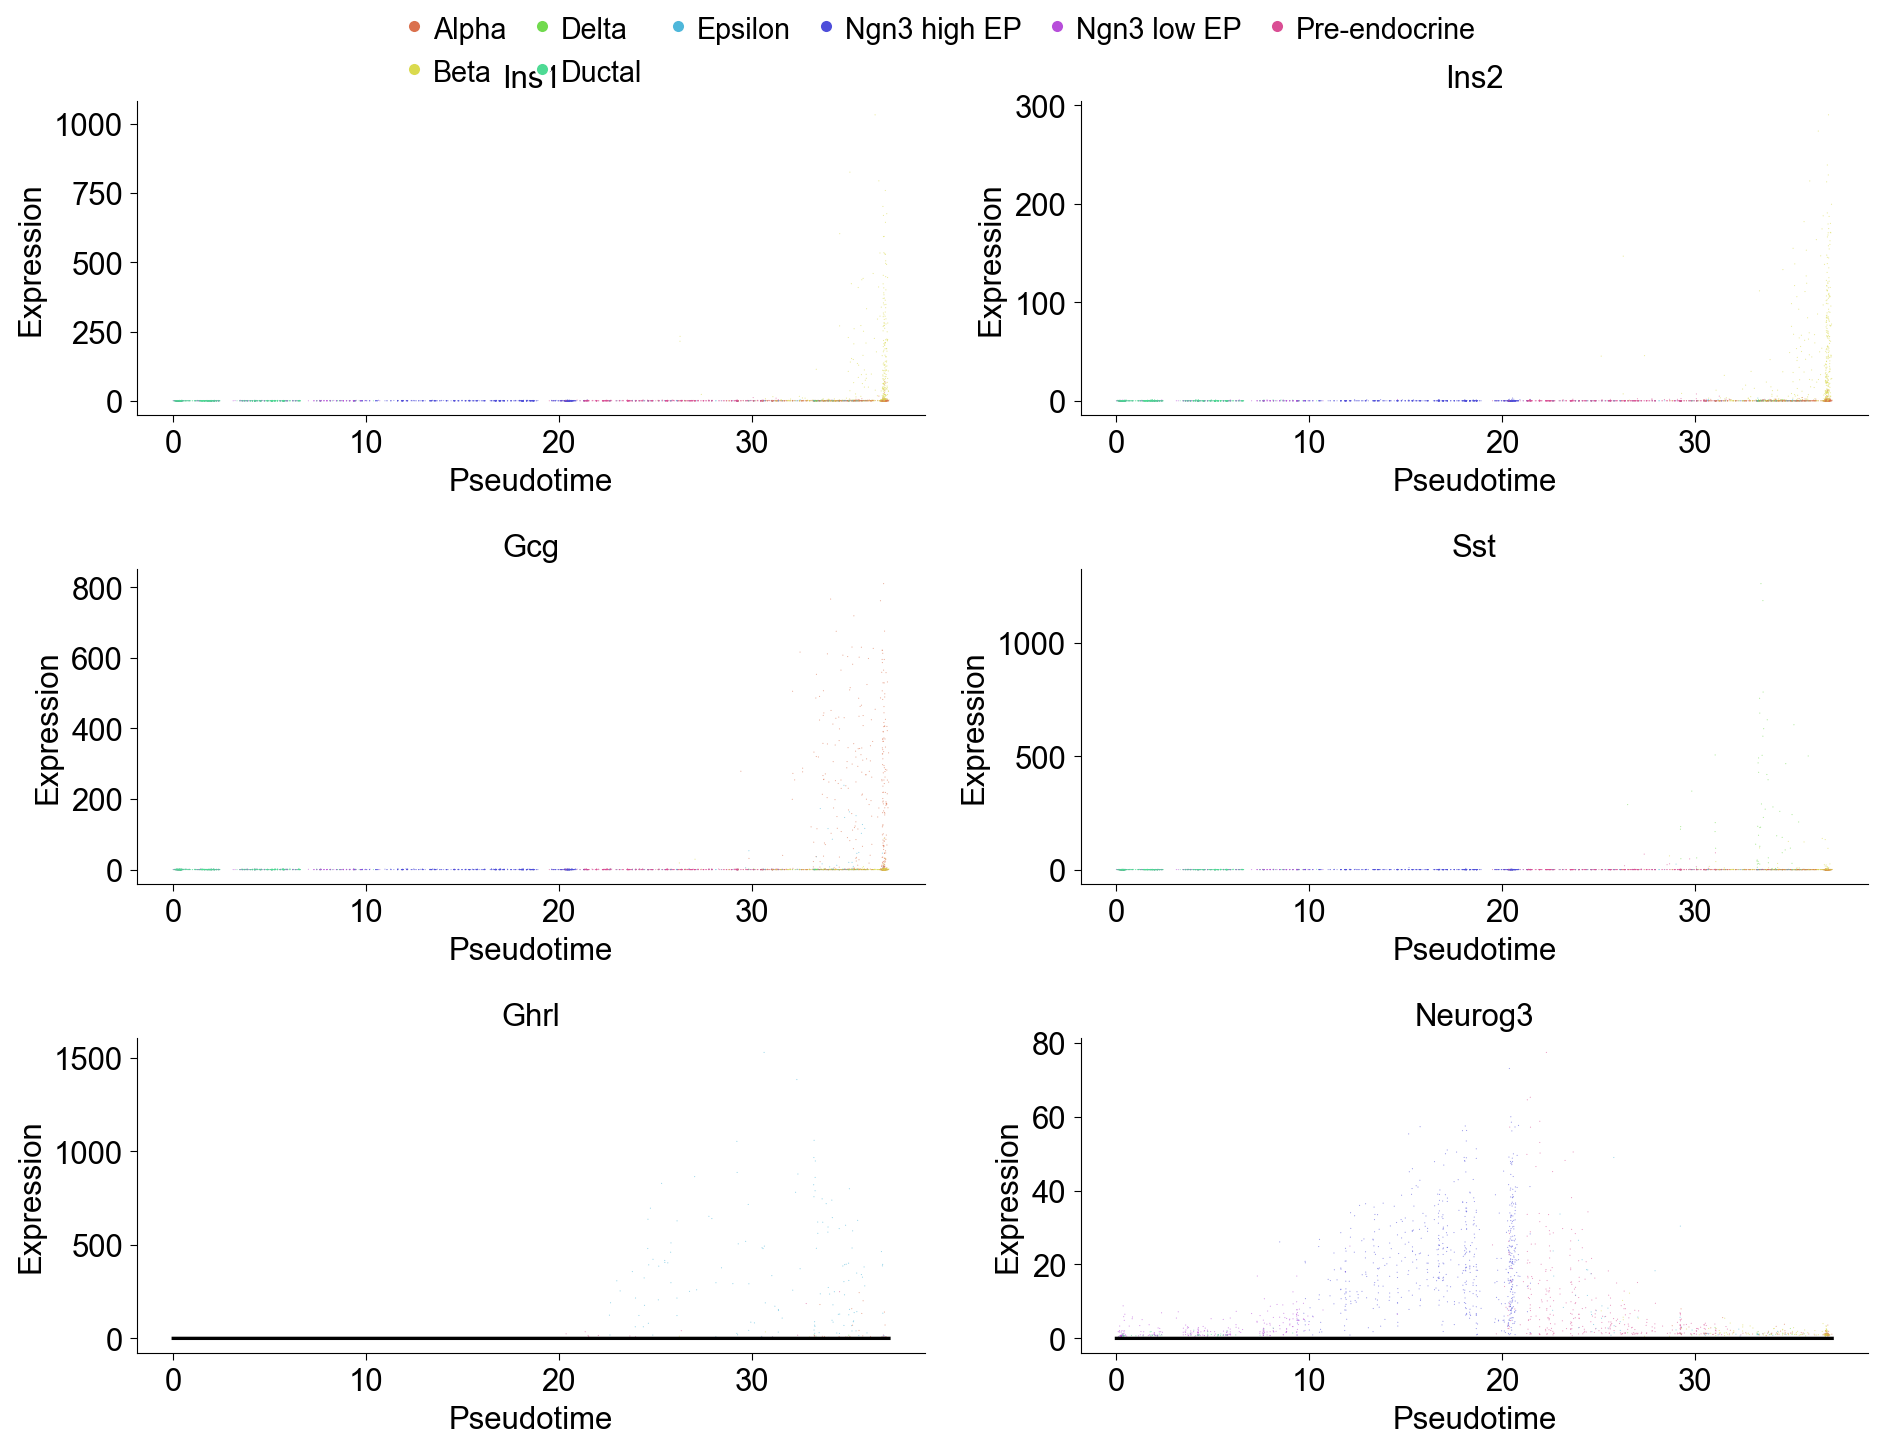

In [13]:
markers = ['Ins1', 'Ins2', 'Gcg', 'Sst', 'Ghrl', 'Neurog3']
markers_found = [g for g in markers if g in mono.adata.var_names]
print(f'Markers: {markers_found}')

mono.plot_genes_in_pseudotime(markers_found, color_by='clusters',
                                ncol=2, cell_size=0.5, figsize=(12, 9))
plt.show()

## 12. Branch-point DE (BEAM)

In [14]:
%%time
branch_points = mono.branch_points
print(f'Branch points: {branch_points}')

if len(branch_points) >= 1:
    beam = mono_ord.BEAM(branch_point=1, cores=-1)
    sig_beam = beam[beam['qval'] < 0.01]
    print(f'\nBEAM Significant genes: {len(sig_beam)}/{len(beam)}')
    print(beam.sort_values('qval').head(10)[['pval','qval']])

Branch points: ['Y_154', 'Y_163']



BEAM Significant genes: 117/953
               pval  qval
index                    
Tmem27          0.0   0.0
Ubqln2          0.0   0.0
Usp51           0.0   0.0
Wnk3            0.0   0.0
Pak3            0.0   0.0
Rbp1            0.0   0.0
Cmtm7           0.0   0.0
2010107G23Rik   0.0   0.0
Maob            0.0   0.0
Prss50          0.0   0.0
CPU times: user 258 ms, sys: 99.6 ms, total: 358 ms
Wall time: 25.6 s


## Summary

Strengths of the `Monocle` class:

- **Single stateful object** — no need to thread `adata` through every call
- **Chainable** — `.preprocess().select_ordering_genes().reduce_dimension().order_cells()`
- **Property accessors** — `mono.pseudotime`, `mono.branch_points`
- **All results written to `adata`** — stays compatible with scanpy

### Performance

| Step | R Monocle 2 | `ov.single.Monocle` | Speed-up |
|------|----------:|--------------------:|---------:|
| DDRTree | 185 s | 7 s | **26×** |
| DE test | 22 s | 14 s | 1.6× |
| BEAM | 29 s | 20 s | 1.4× |